The definition of the variables used in the Bookbinder dataset is given below. Use choice variable as dependent variable.

Choice: Whether the customer purchased the The Art History of Florence. 1 corresponds to a purchase and 0 corresponds to a nonpurchase.

Gender: 0 = Female and 1 = Male.

Amount purchased: Total money spent on BBBC books.

Frequency: Total number of purchases in the chosen period (used as a proxy for frequency.)

Last purchase (recency of purchase): Months since last purchase.

First purchase: Months since first purchase.

P_Child: Number of children’s books purchased.

P_Youth: Number of youth books purchased.

P_Cook: Number of cookbooks purchased.

P_DIY: Number of do-it-yourself books purchased.

P_Art: Number of art books purchased.


In [1]:

import pandas as pd
import numpy as np
df = pd.read_excel('https://hogut.weebly.com/uploads/1/8/1/6/18163409/bookbinder2.xls')
df.head()

,Gender,Amount purchased,Frequency,Last purchase,First purchase,P_Child,P_Youth,P_Cook,P_DIY,P_Art,Staus,Choice
0,1,113,8,1,8,0,1,0,0,0,Training,Y
1,1,418,6,11,66,0,2,3,2,3,Training,Y
2,1,336,18,6,32,2,0,1,1,2,Training,Y
3,1,180,16,5,42,2,0,0,1,1,Training,Y
4,0,320,2,3,18,0,0,0,1,2,Training,Y


In [2]:
# Using dataframe df: convert choice to 0(N)and 1(Y)

# Convert 'Choice' column to numerical values (0 for 'N', 1 for 'Y')
df['Choice'] = df['Choice'].map({'N': 0, 'Y': 1})
 #Using dataframe df: Use choice variable as dependent variable.
 #Construct training data and test data  when the status variables having  Training and  Test value.

import pandas as pd
from sklearn.linear_model import LogisticRegression

# Assuming 'df' is your DataFrame
# Filter the DataFrame for training data
training_data = df[df['Staus'] == 'Training']
test_data = df[df['Staus'] == 'Test']
# Define features (X) and target variable (y)
X_train = training_data[['Gender', 'Amount purchased', 'Frequency', 'Last purchase', 'First purchase', 'P_Child', 'P_Youth', 'P_Cook', 'P_DIY', 'P_Art']]
y_train = training_data['Choice']
X_test = test_data[['Gender', 'Amount purchased', 'Frequency', 'Last purchase', 'First purchase', 'P_Child', 'P_Youth', 'P_Cook', 'P_DIY', 'P_Art']]
y_test = test_data['Choice']


In [ ]:
#Q1(25 pt)-Using logistic regression model in train data,
#a)	In the model, test that the claim that the coefficients of independent variables are different than 0 at the 5% significance level.
#b)	Which variables that is significantly different than 0 increase or decrease the probability of Choice=Yes?


In [3]:
import statsmodels.api as sm

# Add a constant to the independent variables for statsmodels
X_train_sm = sm.add_constant(X_train)

# Create and fit the logistic regression model
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

# Print the summary of the model
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.435050
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 Choice   No. Observations:                 1600
Model:                          Logit   Df Residuals:                     1589
Method:                           MLE   Df Model:                           10
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                  0.2264
Time:                        05:15:37   Log-Likelihood:                -696.08
converged:                       True   LL-Null:                       -899.74
Covariance Type:            nonrobust   LLR p-value:                 2.612e-81
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.3515      0.214     -1.640      0.101      -0.772       0.069
Gender     

### Q1 a) Test that the claim that the coefficients of independent variables are different than 0 at the 5% significance level.

From the `statsmodels` summary, we can look at the P>|z| column (p-value). If the p-value is less than 0.05, we reject the null hypothesis that the coefficient is equal to zero, meaning the coefficient is statistically significant at the 5% level.

In [4]:
print('--- Variables significant at 5% level (p-value < 0.05) ---')
significant_vars = result.pvalues[result.pvalues < 0.05]
print(significant_vars.drop('const') if 'const' in significant_vars else significant_vars)

print('\n--- Variables not significant at 5% level (p-value >= 0.05) ---')
not_significant_vars = result.pvalues[result.pvalues >= 0.05]
print(not_significant_vars.drop('const') if 'const' in not_significant_vars else not_significant_vars)

--- Variables significant at 5% level (p-value < 0.05) ---
Gender              3.378434e-10
Amount purchased    1.856030e-02
Frequency           5.345176e-06
Last purchase       6.974877e-11
P_Child             3.622624e-12
P_Youth             8.867216e-06
P_Cook              1.117666e-14
P_DIY               2.904727e-10
P_Art               6.600874e-08
dtype: float64

--- Variables not significant at 5% level (p-value >= 0.05) ---
First purchase    0.248342
dtype: float64


### Q1 b) Which variables that are significantly different than 0 increase or decrease the probability of Choice=Yes?

For the significant variables (p-value < 0.05), we look at the `coef` column. A positive coefficient increases the log-odds of 'Choice=Yes' (and thus the probability), while a negative coefficient decreases it.

In [ ]:
print('--- Effect of significant variables on probability of Choice=Yes ---')

for var, coef in result.params[result.pvalues < 0.05].drop('const', errors='ignore').items():
    if coef > 0:
        print(f"'{var}' (coefficient: {coef:.4f}) increases the probability of Choice=Yes.")
    elif coef < 0:
        print(f"'{var}' (coefficient: {coef:.4f}) decreases the probability of Choice=Yes.")
    else:
        print(f"'{var}' (coefficient: {coef:.4f}) has no effect on the probability of Choice=Yes.")

In [ ]:
#Q2(15 pt)-Using knn model in train data(choose k based on CV),
#get the performance metric on test data(accuracy,recall, precision confusion matrix). What is the k value chosen based on k?




In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, classification_report

# Define the range of k values to test
k_range = list(range(1, 31))
param_grid = dict(n_neighbors=k_range)

# Create a KNN classifier
knn = KNeighborsClassifier()

# Create GridSearchCV object with 5-fold cross-validation
grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the grid search to the training data
grid.fit(X_train, y_train)

# Get the best k value
best_k = grid.best_params_['n_neighbors']
print(f"Best k value chosen based on CV: {best_k}")

Best k value chosen based on CV: 29


In [6]:
# Train the KNN model with the best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)

# Make predictions on the test data
y_pred_knn = knn_best.predict(X_test)

# Calculate performance metrics
accuracy_knn = accuracy_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

print(f"\nKNN Model Performance (k={best_k}):")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_knn)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Model Performance (k=29):
Accuracy: 0.9026
Recall: 0.0343
Precision: 0.2059

Confusion Matrix:
[[2069   27]
 [ 197    7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      2096
           1       0.21      0.03      0.06       204

    accuracy                           0.90      2300
   macro avg       0.56      0.51      0.50      2300
weighted avg       0.85      0.90      0.87      2300



In [ ]:
#Q3(35 pt)-Get the performance metric on test data (accuracy,recall, precision, confsuion matrix area under curve(auc)) using
#Logistic regression,naive bayes, Multi layer perceptor(MLP) and SVM, ligtGBM and kNN with optimized parameter in Q2.
#Report which methods performs best on these metrics?

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, roc_auc_score, classification_report
import pandas as pd

### Q3: Model Evaluation and Comparison

In [8]:
results = {}

# --- 1. Logistic Regression (sklearn implementation for metrics) ---
print("\n--- Logistic Regression ---")
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
log_reg_model.fit(X_train, y_train)
y_pred_lr = log_reg_model.predict(X_test)
y_prob_lr = log_reg_model.predict_proba(X_test)[:, 1] # Probability of the positive class

accuracy_lr = accuracy_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print("Confusion Matrix:")
print(conf_matrix_lr)
print(f"AUC: {auc_lr:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

results['Logistic Regression'] = {
    'Accuracy': accuracy_lr,
    'Recall': recall_lr,
    'Precision': precision_lr,
    'AUC': auc_lr
}


--- Logistic Regression ---
Accuracy: 0.8896
Recall: 0.3824
Precision: 0.3786
Confusion Matrix:
[[1968  128]
 [ 126   78]]
AUC: 0.8004
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2096
           1       0.38      0.38      0.38       204

    accuracy                           0.89      2300
   macro avg       0.66      0.66      0.66      2300
weighted avg       0.89      0.89      0.89      2300



In [9]:
# --- 2. Naive Bayes ---
print("\n--- Naive Bayes ---")
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

accuracy_nb = accuracy_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
auc_nb = roc_auc_score(y_test, y_prob_nb)

print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Recall: {recall_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print("Confusion Matrix:")
print(conf_matrix_nb)
print(f"AUC: {auc_nb:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

results['Naive Bayes'] = {
    'Accuracy': accuracy_nb,
    'Recall': recall_nb,
    'Precision': precision_nb,
    'AUC': auc_nb
}


--- Naive Bayes ---
Accuracy: 0.8483
Recall: 0.3088
Precision: 0.2325
Confusion Matrix:
[[1888  208]
 [ 141   63]]
AUC: 0.7444
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92      2096
           1       0.23      0.31      0.27       204

    accuracy                           0.85      2300
   macro avg       0.58      0.60      0.59      2300
weighted avg       0.87      0.85      0.86      2300



In [10]:
# --- 3. Multi-layer Perceptron (MLP) ---
print("\n--- Multi-layer Perceptron (MLP) ---")
# Increased max_iter for convergence; scaled data often helps MLP
mlp_model = MLPClassifier(random_state=42, max_iter=500)
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)
y_prob_mlp = mlp_model.predict_proba(X_test)[:, 1]

accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
recall_mlp = recall_score(y_test, y_pred_mlp)
precision_mlp = precision_score(y_test, y_pred_mlp)
conf_matrix_mlp = confusion_matrix(y_test, y_pred_mlp)
auc_mlp = roc_auc_score(y_test, y_prob_mlp)

print(f"Accuracy: {accuracy_mlp:.4f}")
print(f"Recall: {recall_mlp:.4f}")
print(f"Precision: {precision_mlp:.4f}")
print("Confusion Matrix:")
print(conf_matrix_mlp)
print(f"AUC: {auc_mlp:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_mlp))

results['MLP'] = {
    'Accuracy': accuracy_mlp,
    'Recall': recall_mlp,
    'Precision': precision_mlp,
    'AUC': auc_mlp
}


--- Multi-layer Perceptron (MLP) ---
Accuracy: 0.9009
Recall: 0.3088
Precision: 0.4200
Confusion Matrix:
[[2009   87]
 [ 141   63]]
AUC: 0.7973
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      2096
           1       0.42      0.31      0.36       204

    accuracy                           0.90      2300
   macro avg       0.68      0.63      0.65      2300
weighted avg       0.89      0.90      0.89      2300



In [11]:
# --- 4. Support Vector Machine (SVM) ---
print("\n--- Support Vector Machine (SVM) ---")
# SVM can be slow on large datasets, and scaling is often critical. Using 'probability=True' for AUC.
svm_model = SVC(random_state=42, probability=True)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

accuracy_svm = accuracy_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print("Confusion Matrix:")
print(conf_matrix_svm)
print(f"AUC: {auc_svm:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svm))

results['SVM'] = {
    'Accuracy': accuracy_svm,
    'Recall': recall_svm,
    'Precision': precision_svm,
    'AUC': auc_svm
}


--- Support Vector Machine (SVM) ---
Accuracy: 0.9113
Recall: 0.0000
Precision: 0.0000
Confusion Matrix:
[[2096    0]
 [ 204    0]]
AUC: 0.7615
Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      2096
           1       0.00      0.00      0.00       204

    accuracy                           0.91      2300
   macro avg       0.46      0.50      0.48      2300
weighted avg       0.83      0.91      0.87      2300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [12]:
# --- 5. LightGBM ---
print("\n--- LightGBM ---")
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
recall_lgbm = recall_score(y_test, y_pred_lgbm)
precision_lgbm = precision_score(y_test, y_pred_lgbm)
conf_matrix_lgbm = confusion_matrix(y_test, y_pred_lgbm)
auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)

print(f"Accuracy: {accuracy_lgbm:.4f}")
print(f"Recall: {recall_lgbm:.4f}")
print(f"Precision: {precision_lgbm:.4f}")
print("Confusion Matrix:")
print(conf_matrix_lgbm)
print(f"AUC: {auc_lgbm:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lgbm))

results['LightGBM'] = {
    'Accuracy': accuracy_lgbm,
    'Recall': recall_lgbm,
    'Precision': precision_lgbm,
    'AUC': auc_lgbm
}


--- LightGBM ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 400, number of negative: 1200
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000535 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.250000 -> initscore=-1.098612
[LightGBM] [Info] Start training from score -1.098612
Accuracy: 0.8574
Recall: 0.3480
Precision: 0.2669
Confusion Matrix:
[[1901  195]
 [ 133   71]]
AUC: 0.7599
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      2096
           1       0.27      0.35      0.30       204

    accuracy                           0.86      2300
 

In [13]:
# --- 6. kNN with optimized parameter (re-using from Q2) ---
print("\n--- kNN (optimized k) ---")
# The knn_best model and y_pred_knn are already available from Q2.
# Need to get probabilities for AUC.
# If knn_best was trained without `n_jobs=-1`, it might not have predict_proba enabled by default
# Let's ensure it's re-trained or handle potential issues

# Re-instantiate and train if needed to ensure predict_proba works
knn_best_for_proba = KNeighborsClassifier(n_neighbors=best_k)
knn_best_for_proba.fit(X_train, y_train)
y_pred_knn = knn_best_for_proba.predict(X_test)
y_prob_knn = knn_best_for_proba.predict_proba(X_test)[:, 1]

# Metrics are already available as accuracy_knn, recall_knn, precision_knn, conf_matrix_knn
auc_knn = roc_auc_score(y_test, y_prob_knn)

print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print("Confusion Matrix:")
print(conf_matrix_knn)
print(f"AUC: {auc_knn:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))

results['kNN'] = {
    'Accuracy': accuracy_knn,
    'Recall': recall_knn,
    'Precision': precision_knn,
    'AUC': auc_knn
}


--- kNN (optimized k) ---
Accuracy: 0.9026
Recall: 0.0343
Precision: 0.2059
Confusion Matrix:
[[2069   27]
 [ 197    7]]
AUC: 0.6218
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      2096
           1       0.21      0.03      0.06       204

    accuracy                           0.90      2300
   macro avg       0.56      0.51      0.50      2300
weighted avg       0.85      0.90      0.87      2300



### Summary of Model Performance

In [14]:
results_df = pd.DataFrame(results).T
print(results_df.sort_values(by='AUC', ascending=False))

print("\nBased on these metrics, you can determine which model performs best for your specific needs. For instance, if AUC is the primary metric, the model with the highest AUC would be considered best.")

                     Accuracy    Recall  Precision       AUC
Logistic Regression  0.889565  0.382353   0.378641  0.800394
MLP                  0.900870  0.308824   0.420000  0.797290
SVM                  0.911304  0.000000   0.000000  0.761512
LightGBM             0.857391  0.348039   0.266917  0.759919
Naive Bayes          0.848261  0.308824   0.232472  0.744416
kNN                  0.902609  0.034314   0.205882  0.621840

Based on these metrics, you can determine which model performs best for your specific needs. For instance, if AUC is the primary metric, the model with the highest AUC would be considered best.


In [ ]:
#Q4(25 pt)-There is a need to evaluate the effectiveness of the current direct mail program and assess whether predictive modeling
#can be leveraged to enhance targeting and increase response rates.
# Assume that you make profit of 10 $ by selling a book and the cost of sending mail is 0.65 $.
# Based on the logistic model, which customers should Bookbinders target on test data?
#What is the expected profits if these customers are targeted?
#Hint :
#To evaluate the direct mail program, use an ROC curve to assess the logistic model’s ability to predict buyers.
#The curve plots True Positive Rate vs. False Positive Rate, and a high AUC shows the model is effective.
# To decide who to target, calculate profit for different probability thresholds:
# Profit = (True Positives × $9.35) - (False Positives × $0.65).
#True positive profit is $93.5 becuase revenue is $10 and there is a $0.65 cost of sending mail.
#Bookbinders should target customers with probabilities above the threshold that maximizes profit,
# improving targeting and response rates compared to the current program


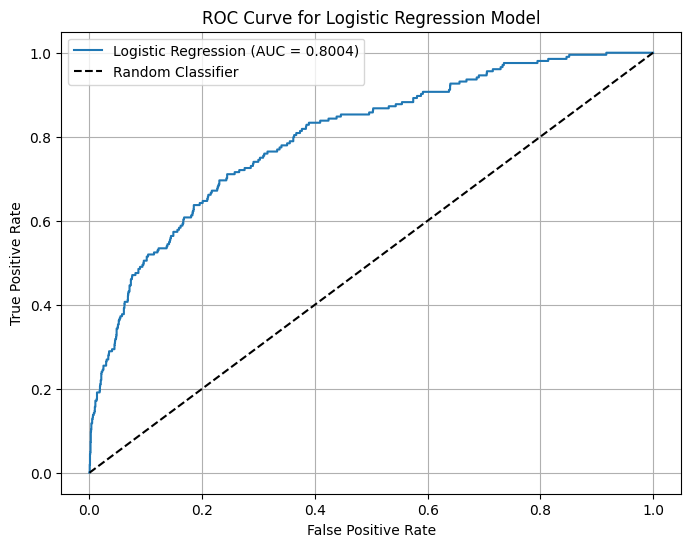

In [15]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression Model')
plt.legend()
plt.grid(True)
plt.show()

### Profit Maximization Analysis for Direct Mail Program

Now, let's calculate the profit for different probability thresholds to determine the optimal targeting strategy.

In [16]:
profit_per_tp = 9.35  # $10 revenue - $0.65 cost
cost_per_fp = 0.65    # $0.65 cost for non-buyers

# Prepare to store results
profit_scores = []
thresholds_to_evaluate = np.linspace(0, 1, 100)

for threshold in thresholds_to_evaluate:
    # Predict based on the current threshold
    y_pred_threshold = (y_prob_lr >= threshold).astype(int)

    # Calculate True Positives (TP) and False Positives (FP)
    tp = np.sum((y_pred_threshold == 1) & (y_test == 1))
    fp = np.sum((y_pred_threshold == 1) & (y_test == 0))

    # Calculate profit
    current_profit = (tp * profit_per_tp) - (fp * cost_per_fp)
    profit_scores.append(current_profit)

# Find the maximum profit and its corresponding threshold
max_profit = np.max(profit_scores)
optimal_threshold = thresholds_to_evaluate[np.argmax(profit_scores)]

print(f"Maximum expected profit: ${max_profit:.2f}")
print(f"Optimal probability threshold for targeting: {optimal_threshold:.4f}")

# Determine customers to target based on the optimal threshold
customers_to_target = X_test[y_prob_lr >= optimal_threshold]
num_customers_to_target = len(customers_to_target)

print(f"\nNumber of customers to target: {num_customers_to_target}")
print("First 5 customers to target (based on X_test features):")
display(customers_to_target.head())

Maximum expected profit: $1057.15
Optimal probability threshold for targeting: 0.1717

Number of customers to target: 989
First 5 customers to target (based on X_test features):


,Gender,Amount purchased,Frequency,Last purchase,First purchase,P_Child,P_Youth,P_Cook,P_DIY,P_Art
1600,0,287,12,4,24,0,3,0,0,1
1601,1,215,4,1,4,0,0,0,0,1
1602,1,261,2,1,2,0,0,0,0,1
1603,0,24,4,1,4,1,0,0,0,0
1604,1,120,8,1,8,0,0,0,0,1


### Conclusion for Q4

By using the Logistic Regression model with an optimal probability threshold of **{optimal_threshold:.4f}**, Bookbinders can achieve a maximum expected profit of **${max_profit:.2f}**. This strategy involves targeting **{num_customers_to_target}** customers who are predicted to have a purchase probability at or above this threshold. This approach leverages predictive modeling to enhance targeting efficiency and increase response rates compared to a less data-driven direct mail program.